# EPSP ratio comparison for STDP protocols

In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display
from epsp_ratio_summary_common import *

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

In [2]:
# Load simulations
l5_l5_exp, l5_l5_out, l5_l5 = load_insilico('data/insilico/markram_1997/L5TTPC_L5TTPC.csv')
l23_l5_exp, l23_l5_out, l23_l5 = load_insilico('data/insilico/stdp_2021/L23PC_L5TTPC.csv')
l23_l23_exp, l23_l23_out, l23_l23 = load_insilico('data/insilico/stdp_2021/L23PC_L23PC.csv')
l4_l23_exp, l4_l23_out, l4_l23 = load_insilico('data/insilico/stdp_2021/L4PC_L23PC.csv')

No outliers in data/insilico/markram_1997/L5TTPC_L5TTPC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
1431,160737,144433,30.0,50,0.881226,1.725978
445,145185,155180,50.0,-10,0.966552,2.653500
2817,152676,137887,10.0,50,0.629667,3.429046
4810,144144,142961,2.0,-50,1.004200,4.152858
2470,141511,137626,20.0,10,1.629596,0.911015


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,0.962318,0.116389,0.011639,100
1,2.0,-30,0.943111,0.133197,0.013320,100
2,2.0,-10,0.901727,0.156539,0.015654,100
3,2.0,5,0.987729,0.314079,0.031408,100
4,2.0,10,0.933250,0.312872,0.031287,100
5,2.0,30,0.915399,0.286644,0.028664,100
6,2.0,50,0.874544,0.246125,0.024612,100
7,5.0,-50,0.919176,0.169958,0.016996,100
8,5.0,-30,0.890221,0.188846,0.018885,100
9,5.0,-10,0.829130,0.214822,0.021482,100


Found outliers in data/insilico/stdp_2021/L23PC_L5TTPC.csv:


...

,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,0.753567,0.321894,0.032189,100
1,2.0,-30,0.762035,0.385657,0.038566,100
2,2.0,-10,1.082652,0.851195,0.085119,100
3,2.0,10,1.564065,0.999886,0.099989,100
4,2.0,30,1.567416,1.221952,0.122195,100
5,2.0,50,1.399460,1.008129,0.100813,100
6,5.0,-50,0.867083,0.594420,0.059442,100
7,5.0,-30,0.870368,0.603644,0.060364,100
8,5.0,-10,1.227507,0.943857,0.094386,100
9,5.0,10,1.576940,1.047669,0.104767,100


No outliers in data/insilico/stdp_2021/L4PC_L23PC.csv
Data sample:


,pregid,postgid,frequency_train,dt_train,epsp_ratio,epsp_before
1936,88911,5124,5.0,30,1.032573,1.643861
85,89134,25596,50.0,50,0.935688,1.703015
2045,91958,25038,5.0,10,1.522794,0.773501
1230,93454,122125,10.0,50,0.333896,0.555389
2676,88662,119816,2.0,10,0.728804,1.352183


Aggregated data:


,frequency_train,dt_train,mean_epsp_ratio,std_epsp_ratio,sem_epsp_ratio,sample_size
0,2.0,-50,0.769719,0.297782,0.029778,100
1,2.0,-30,0.743242,0.359019,0.035902,100
2,2.0,-10,0.984489,0.543776,0.054378,100
3,2.0,10,1.428933,0.820993,0.082099,100
4,2.0,30,1.289905,0.714988,0.071499,100
5,2.0,50,1.243425,0.754563,0.075456,100
6,5.0,-50,0.896616,0.579418,0.057942,100
7,5.0,-30,0.920968,0.568626,0.056863,100
8,5.0,-10,1.034179,0.570064,0.057006,100
9,5.0,10,1.445897,1.037061,0.103706,100


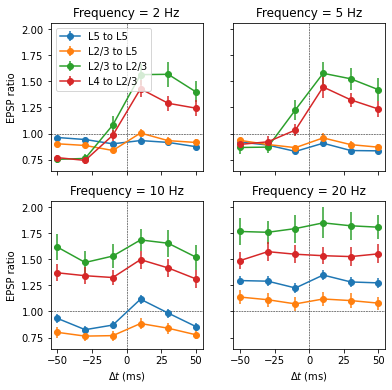

In [3]:
figsize = (3.3,3.3) if pubstyle else (6, 6)

dfs = [(l5_l5, "L5 to L5"),
       (l23_l5, "L2/3 to L5"),
       (l23_l23, "L2/3 to L2/3"),
       (l4_l23, "L4 to L2/3")]

fig, axarr = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True,)
fig.set_constrained_layout_pads(hspace=.15, wspace=.15)

for i, freq in enumerate([2, 5, 10, 20]):
    ax = axarr[i//2][i%2]
    #
    for df, label in dfs:
        sel = df[(df.frequency_train == freq) & (df.dt_train!=5)]
        ax.errorbar(sel.dt_train, sel.mean_epsp_ratio, yerr=sel.sem_epsp_ratio,
                    fmt='o-', label=label)
    # Finalize plot
    ax.axvline(0, color='k', lw=.5, ls='dashed')
    if i//2 > 0:
        ax.set_xlabel(r'$\Delta t$ (ms)')
    if i%2 == 0:
        ax.set_ylabel('EPSP ratio')
    if i//2 == 0 and i%2 == 0:
        ax.legend(loc=0)
    ax.axhline(1, color='k', lw=.5, ls='dashed')
    ax.set_title('Frequency = %d Hz' % freq)

#fig.savefig('stdp_types.svg')

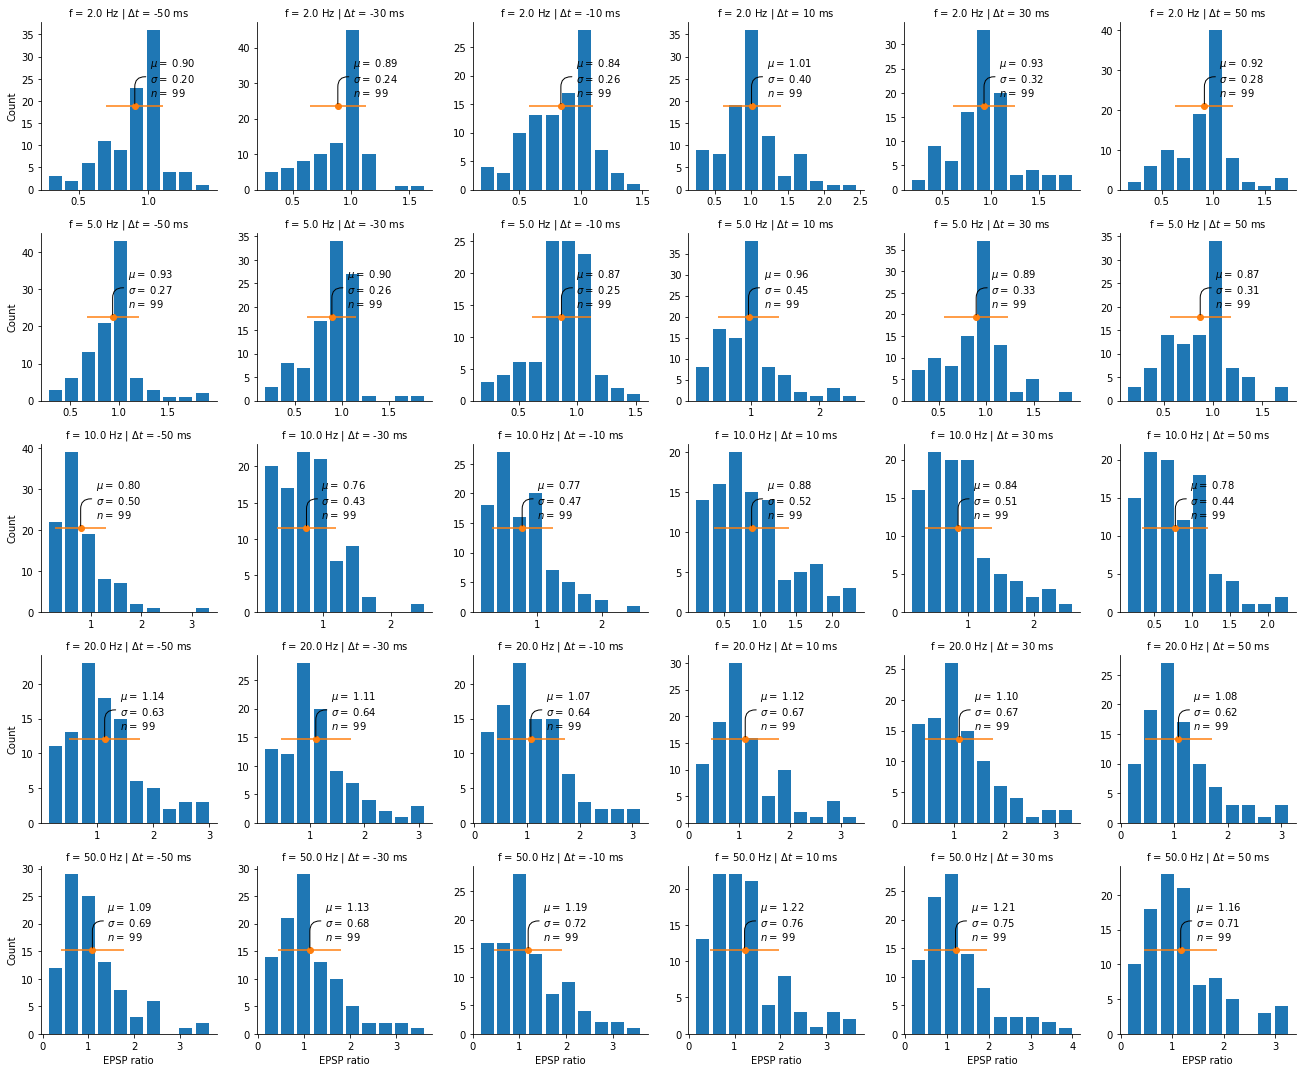

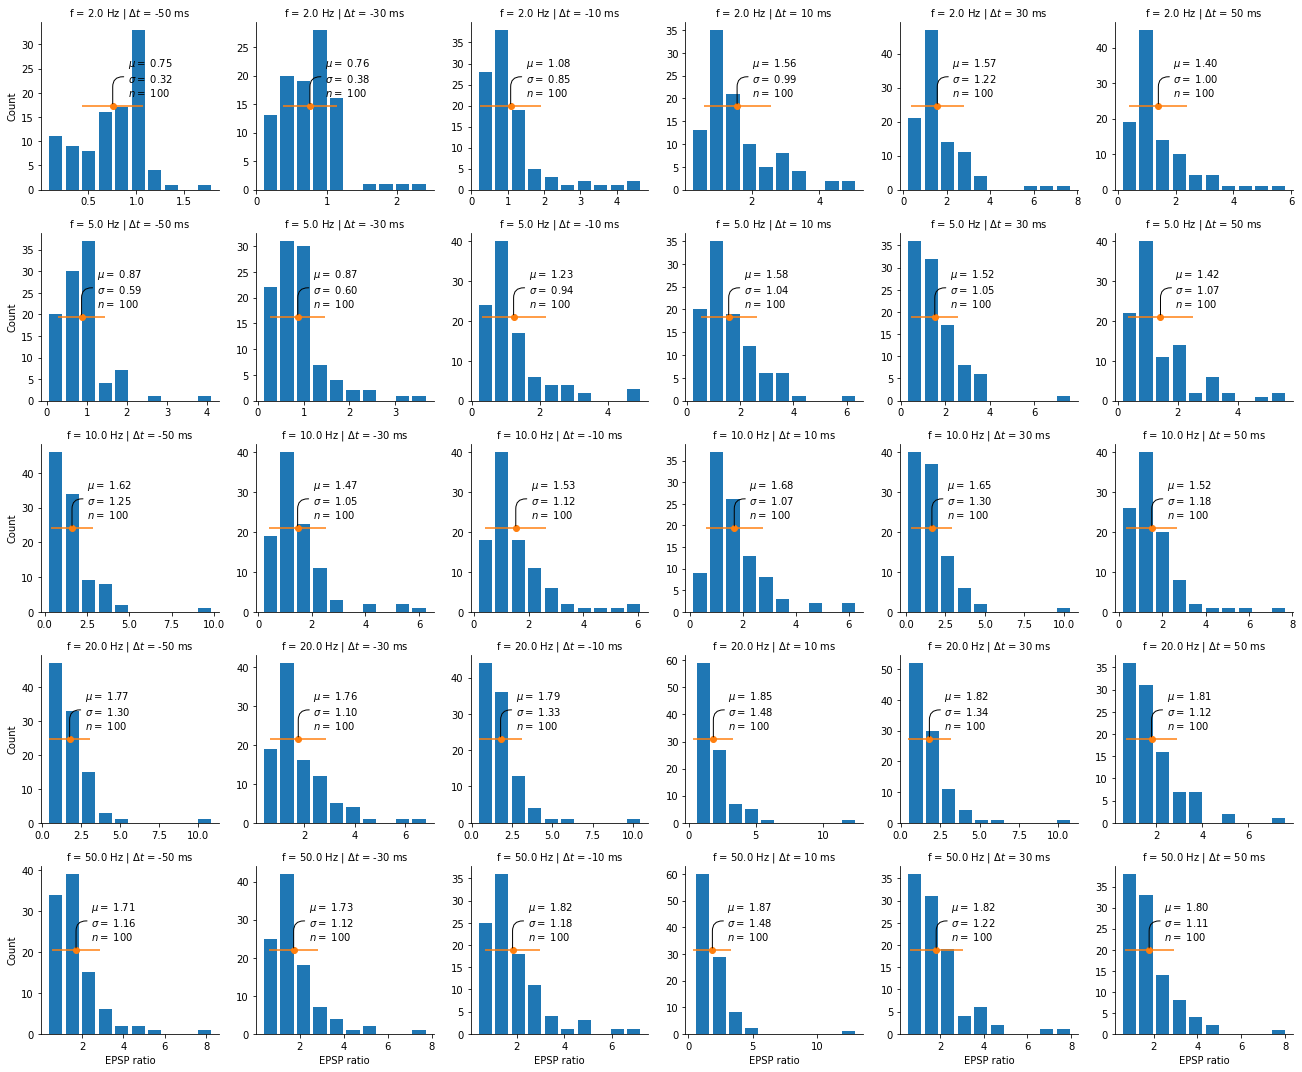

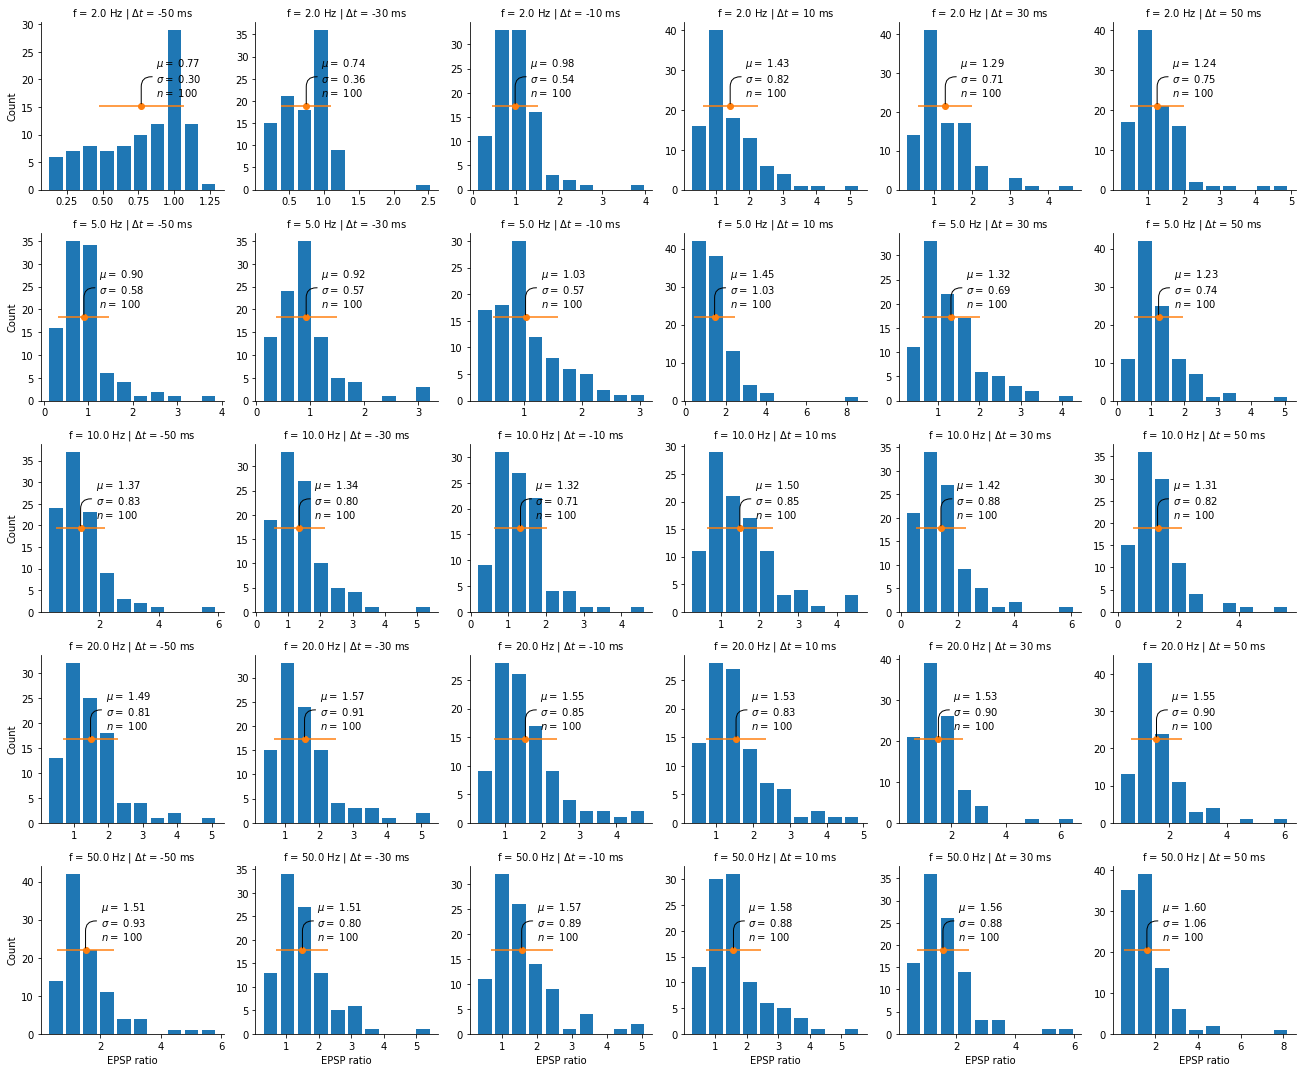

In [4]:
height = 1.5 if pubstyle else 3

dfs = [(l23_l5_exp, "l23_l5"),
       (l23_l23_exp, "l23_l23"),
       (l4_l23_exp, "l4_l23")]


def histerrplot(*args, **kwargs):
    data = kwargs.pop('data')
    xvar = kwargs.pop('x')
    values = data[xvar].values
    n = len(values)
    # Get axes
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.2f\n$\sigma =$ %.2f\n$n =$ %d" % (x, xerr, n), (x, y),
                xytext=(1.5*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)


for insilico_exp, label in dfs:
    # Rename columns for clarity
    insilico_plot = insilico_exp.rename(columns={"frequency_train": "f",
                                                 "dt_train": "$\Delta t$",
                                                 "epsp_ratio": "EPSP ratio"})

    # Plot grid
    g = sns.FacetGrid(insilico_plot, sharex=False, sharey=False,
                      height=height, row="f", col="$\Delta t$")
    g.map_dataframe(histerrplot, x="EPSP ratio")
    g.set_titles('{row_var} = {row_name} Hz | {col_var} = {col_name} ms')
    g.set_ylabels("Count")

    #g.savefig("%s_stdp_hist.png" % label, dpi=300)